# <center>**Examen Final Calculo Numerico**</center>

In [271]:
import numpy as np
import matplotlib.pyplot as plt

## <center>**Problema 1**</center>

**(a)**

In [272]:
def factorial(a):
    
    res = 1
    
    for n in range(1,int(a+1)):
        res = res * n
    
    return res

In [273]:
def binom_factorial(a,b):
    return (factorial(a))/(factorial(b)*factorial(a-b))

Con el siguiente rango de valores de a, es en mejor rango donde podemos ver el ultimo a. Este rango se ha usado para no tener que imprimir 200 valores

In [274]:
a_vals = [float(n) for n in range(1015,1030)]

for a in a_vals:
    
    half_a = a // 2
    
    val = binom_factorial(a,float(half_a))
    print(f"({a} {half_a}) = {val}")

(1015.0 507.0) = 8.786824305415626e+303
(1016.0 508.0) = 1.7573648610831252e+304
(1017.0 508.0) = 3.5112771389421187e+304
(1018.0 509.0) = 7.022554277884237e+304
(1019.0 509.0) = 1.4031338841498113e+305
(1020.0 510.0) = 2.8062677682996225e+305
(1021.0 510.0) = 5.607043818853062e+305
(1022.0 511.0) = 1.1214087637706124e+306
(1023.0 511.0) = 2.2406272760494855e+306
(1024.0 512.0) = 4.481254552098971e+306
(1025.0 512.0) = 8.953773715207495e+306
(1026.0 513.0) = 1.790754743041499e+307
(1027.0 513.0) = 3.5780255274389484e+307
(1028.0 514.0) = 7.156051054877897e+307
(1029.0 514.0) = 1.429820686498904e+308


En el valor a = 1030, ocurre un error de overflow ya que python no puede representar mas numeros con la precision de 64 bits, a = 1029 es el ultimo valor en el que recibimos un resultado finito.

**(b)**

In [275]:
def formula_producto(a,b):
    
    prod = 1
    
    for i in range(1,int(b+1)):
        
        prod = prod * (a - b + i)/(i)
        
    return prod

In [276]:
new_a_vals = [float(n) for n in range(1010,1030)]
for a in new_a_vals:
    
    half_a = a // 2
    
    val = formula_producto(a,float(half_a))
    print(f"({a} {half_a}) = {val}")

(1010.0 505.0) = 2.7540225794833613e+302
(1011.0 505.0) = 5.502602426596193e+302
(1012.0 506.0) = 1.1005204853192386e+303
(1013.0 506.0) = 2.1988703187936664e+303
(1014.0 507.0) = 4.397740637587333e+303
(1015.0 507.0) = 8.786824305415627e+303
(1016.0 508.0) = 1.7573648610831254e+304
(1017.0 508.0) = 3.5112771389421216e+304
(1018.0 509.0) = 7.022554277884243e+304
(1019.0 509.0) = 1.4031338841498128e+305
(1020.0 510.0) = 2.8062677682996257e+305
(1021.0 510.0) = inf
(1022.0 511.0) = inf
(1023.0 511.0) = inf
(1024.0 512.0) = inf
(1025.0 512.0) = inf
(1026.0 513.0) = inf
(1027.0 513.0) = inf
(1028.0 514.0) = inf
(1029.0 514.0) = inf


Aqui llega al infinito en el valor de a = 1021, por lo que el ultimo valor finito es el a = 1020.

**(c)** 

In [277]:
for i in range(160,170):
    
    a = float(i)
    
    print(f"({a} {float (a // 2)})")
    print(f"Binomial: {binom_factorial(a, float(a // 2))}")
    print(f"Producto: {formula_producto(a, float(a // 2))}")

(160.0 80.0)
Binomial: 9.204512581373423e+46
Producto: 9.204512581373417e+46
(161.0 80.0)
Binomial: 1.8295389204952113e+47
Producto: 1.8295389204952117e+47
(162.0 81.0)
Binomial: 3.6590778409904226e+47
Producto: 3.659077840990423e+47
(163.0 81.0)
Binomial: 7.2735327814809626e+47
Producto: 7.273532781480966e+47
(164.0 82.0)
Binomial: 1.4547065562961925e+48
Producto: 1.4547065562961932e+48
(165.0 82.0)
Binomial: 2.8918865275767682e+48
Producto: 2.8918865275767734e+48
(166.0 83.0)
Binomial: 5.7837730551535365e+48
Producto: 5.783773055153547e+48
(167.0 83.0)
Binomial: 1.1498691669174293e+49
Producto: 1.1498691669174281e+49
(168.0 84.0)
Binomial: 2.2997383338348585e+49
Producto: 2.2997383338348562e+49
(169.0 84.0)
Binomial: 4.572420922565778e+49
Producto: 4.572420922565781e+49


In [278]:
np.finfo(float)

finfo(resolution=1e-15, min=-1.7976931348623157e+308, max=1.7976931348623157e+308, dtype=float64)

Ambos metodos son equivalentes ya que obtenemos los mismos resultados.

En el metodo de la binomial, se pueden representar mas valores, el problema es que python usa 64 bits para representar numeros en coma flotante. Como se puede ver, el numero maximo a representar el es $1,79·10^{308}$ por lo que excedemos el numero

## <center>**Problema 2**</center>

In [279]:
def halley(f,df,df2,x0,tol=1.e-8,maxit=50,verbose=True):
    
    xk = x0
    x_next = -1
    k = 0
    r = -1
    C = -1
    errores = []
    
    while k < maxit:
        
        fx = f(xk)
        dfx = df(xk)
        df2x = df2(xk)
        
        x_next = xk - (2*fx*dfx)/((2*dfx)**2 - (fx*df2x))
        
        error = np.abs(x_next - xk)
        errores.append(error)
        
        if len(errores) > 3:
            e3 = errores[-1]
            e2 = errores[-2]
            e1 = errores[-3]
            
            r = np.log(e2/e3)/np.log(e1/e2)
            C = (e2)/(e1**r)
        
        if verbose:
            print(f"k = {k}\t xk = {xk} \t xk+1={x_next} \t error={error} \t r = {r} \t {C}")
        
        if error < tol:
            break
        
        xk = x_next
        k += 1
        
    else:
        print("Numero maximo de iteraciones alcanzado")
    
    return x_next

In [280]:
x0 = 1.3
f = lambda x: x**3 - 2
df = lambda x: 3*x**2
df2 = lambda x: 6*x

root = halley(f,df,df2,x0,verbose=True)

k = 0	 xk = 1.3 	 xk+1=1.2802772429726608 	 error=0.019722757027339277 	 r = -1 	 -1
k = 1	 xk = 1.2802772429726608 	 xk+1=1.2701811248872377 	 error=0.0100961180854231 	 r = -1 	 -1
k = 2	 xk = 1.2701811248872377 	 xk+1=1.2650719456086879 	 error=0.005109179278549814 	 r = -1 	 -1
k = 3	 xk = 1.2650719456086879 	 xk+1=1.26250175863147 	 error=0.002570186977217892 	 r = 1.0087326415697349 	 0.5267756900772312
k = 4	 xk = 1.26250175863147 	 xk+1=1.2612127253288445 	 error=0.0012890333026254197 	 r = 1.0044042141947251 	 0.5148805532179577
k = 5	 xk = 1.2612127253288445 	 xk+1=1.2605672186124506 	 error=0.0006455067163939621 	 r = 1.0022115110862528 	 0.5081913992069708
k = 6	 xk = 1.2605672186124506 	 xk+1=1.2602442170957977 	 error=0.0003230015166528766 	 r = 1.001108096389579 	 0.5044739366913141
k = 7	 xk = 1.2602442170957977 	 xk+1=1.2600826542173813 	 error=0.00016156287841639916 	 r = 1.0005546320393786 	 0.5024271821461334
k = 8	 xk = 1.2600826542173813 	 xk+1=1.2600018572380787 

In [281]:
print(root)

1.2599210597596833


## <center>**Problema 3**<center>

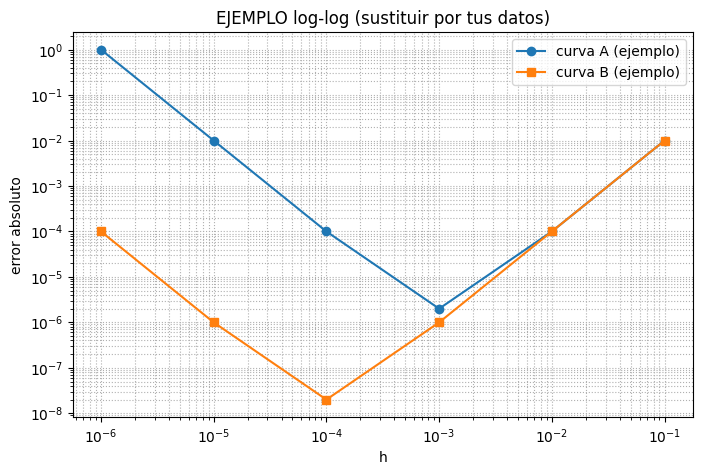

**(a)**

Para calcular la función estable, tenemos que multiplicar y dividir por el conjugado del termino que produce la cancelación catastrofica

$$
\frac{1 - cos(x)}{x^2} = \frac{1 - cos(x)}{x^2} · \frac{1 + cos(x)}{1 + cos(x)} = \frac{sen^2(x)}{x^2(1 + cos(x))}
$$

In [284]:
f_naive = lambda x: (1-np.cos(x))/(x**2)

f_estable = lambda x: (np.sin(x)**2)/(x**2*(1+np.cos(x)))

x_vals = [10**-n for n in range(4,10)]

for x in x_vals:
    print(f"{f_estable(x)}")

0.4999999995833334
0.4999999999958333
0.4999999999999583
0.4999999999999995
0.5
0.5


**(b)**

In [285]:
def df2_c(f,x,h):
    return (f(x+h) - 2*f(x) + f(x-h))/(h**2)

In [288]:
hs = np.array([1e-1, 1e-2, 1e-3, 1e-4, 1e-5,1e-6,1e-7,1e-8])
x0 = 0.004

errores_naive = []
errores_estable = []

true_val = -0.07771561182376097

for h in hs:
    
    d_naive = df2_c(f_naive,x0,h)
    d_estable = df2_c(f_estable,x0,h)
    
    print(f"{h:.0e}")
    print(f"Valor naive = {d_naive}")
    print(f"Valor Estable = {d_estable}")
    
    errores_naive.append(np.abs(true_val - d_naive))
    errores_estable.append(np.abs(true_val - d_estable))

1e-01
Valor naive = -0.08330529370793592
Valor Estable = -0.08330529396788354
1e-02
Valor naive = -0.08333276906857812
Valor Estable = -0.08333278889383067
1e-03
Valor naive = -0.08333093476364795
Valor Estable = -0.08333306406038687
1e-04
Valor naive = -0.08324693157035767
Valor Estable = -0.08333309042818371
1e-05
Valor naive = -0.06394329510328588
Valor Estable = -0.08333278511685192
1e-06
Valor naive = 5.972500272122261
Valor Estable = -0.08343326030058051
1e-07
Valor naive = -49.53815135877449
Valor Estable = -0.07771561172376097
1e-08
Valor naive = 76278.42801838368
Valor Estable = -2.2204460492503126


**(c)**

Como no soy capaz de encontrar el valor real de la función explicare lo que deberia ocurrir, una vez encontrados todos los errores los podriamos en la escala logaritmica.

Lo que veriamos es que para los valores de h mas grandes veriamos una bajada de ya que aqui predomina el error de discretización. Bajaria hasta cierto punto donde volveria empezar a subir.

Esto ocurre porque a valores muy pequeños de h, empieza a predominar el valor de redondeo.

Encontrariamos un h optimo.

Segun los valores analizados, estimo que deberiamos ver el h optimo en $h=10^{-7}$

In [ ]:
hs = np.array([1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6])   # datos ficticios
err_A = hs**2 + 1e-12 / hs**2                          # curva inventada (forma en "V")
err_B = hs**2 + 1e-16 / hs**2                          # otra curva inventada

In [ ]:
plt.figure(figsize=(8, 5))
plt.loglog(hs, err_A, 'o-', label='curva A (ejemplo)')
plt.loglog(hs, err_B, 's-', label='curva B (ejemplo)')
plt.xlabel('h')
plt.ylabel('error absoluto')
plt.title('EJEMPLO log-log (sustituir por tus datos)')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.savefig('ejemplo_loglog.png', dpi=120, bbox_inches='tight')